In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Combine inference results of each algorithm* 

(skip this step if you already have a combined dataframe)

In [ ]:
MAP_NAME = "ToyExample-v2"
ALGORITHMS = ["vdn_rnn", "qmix_rnn", "pqn_rnn", "mappo_rnn", "ippo_rnn"]

inference_dfs = []

# combine the results of all algorithms
for alg in ALGORITHMS:
    try:
        # Load the training results for each algorithm
        _df = pd.read_csv(f'./{MAP_NAME}/inference_results_{alg}.csv')
    except FileNotFoundError:
        print(f"Training results for {alg} not found.")
        continue

    inference_dfs.append(_df)

# Concatenate all dataframes into one
inference_df = pd.concat(inference_dfs, ignore_index=True)

# count the number of algorithms, seeds, and checkpoints in the dataframe
num_algorithms = len(inference_df['algorithm'].unique())
num_runs = len(inference_df['WANDB_RUN_ID'].unique())
num_checkpoints = len(inference_df['checkpoint_dir_name'].unique())

print(f"Number of algorithms: {num_algorithms}")
print(f"Number of runs: {num_runs}")
print(f"Number of checkpoints: {num_checkpoints}")

# sort according to algorithm, then by checkpoint_id
inference_df['algorithm'] = pd.Categorical(inference_df['algorithm'], categories=ALGORITHMS, ordered=True)
inference_df = inference_df.sort_values(by=['algorithm', 'checkpoint_id']).reset_index(drop=True)

# save the combined dataframe to a CSV file
# inference_df.to_csv(f'./{MAP_NAME}/inference_results_combined.csv', index=False)

### Load the results

download the inference results from the provided URL

In [2]:
# ToyExample-v2
MAP_NAME = "ToyExample-v2"
!wget "https://surfdrive.surf.nl/files/index.php/s/G8XWW8On5MWhtCk/download?path=%2FToyExample-v2%2Finference&files=inference_results_ToyExample-v2.csv" -O inference_results_ToyExample-v2.csv

inference_df = pd.read_csv('inference_results_ToyExample-v2.csv')

--2025-04-30 22:45:10--  https://surfdrive.surf.nl/files/index.php/s/G8XWW8On5MWhtCk/download?path=%2FToyExample-v2%2Finference&files=inference_results_ToyExample-v2.csv
Resolving surfdrive.surf.nl (surfdrive.surf.nl)... 2001:610:10b:2:0:a11:da7a:5afe, 2001:610:108:203b:0:a11:da7a:5afe, 2001:610:10a:2:0:a11:da7a:5afe, ...
Connecting to surfdrive.surf.nl (surfdrive.surf.nl)|2001:610:10b:2:0:a11:da7a:5afe|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 807572 (789K) [text/csv]
Saving to: ‘inference_results_ToyExample-v2.csv’

inference_results_T 100%[===================>] 788,64K  --.-KB/s    in 0,1s    

2025-04-30 22:45:10 (7,80 MB/s) - ‘inference_results_ToyExample-v2.csv’ saved [807572/807572]



In [3]:
inference_df.drop(columns=['VMAPPED_SEED', 'eval_seed'], inplace=True)

inference_df

,map_name,algorithm,checkpoint_dir_name,WANDB_RUN_ID,checkpoint_id,mean,std_err,lower_ci,upper_ci,bst_std_err
0,ToyExample-v2,vdn_rnn,2025-04-28_15-09-01.245724,7lohtipg,120,-7.439863e+08,2.093576e+06,-7.480978e+08,-7.398864e+08,2.081817e+06
1,ToyExample-v2,vdn_rnn,2025-04-28_15-32-01.241052,n8ssiec7,120,-9.036231e+08,1.958708e+06,-9.074671e+08,-8.998245e+08,1.959141e+06
2,ToyExample-v2,vdn_rnn,2025-04-28_15-55-31.234978,mx28svex,120,-1.063503e+09,1.759676e+06,-1.066852e+09,-1.060093e+09,1.742924e+06
3,ToyExample-v2,vdn_rnn,2025-04-28_16-18-10.947877,iuledbla,120,-1.070539e+09,1.645847e+06,-1.073753e+09,-1.067400e+09,1.644446e+06
4,ToyExample-v2,vdn_rnn,2025-04-28_16-41-42.951815,ehgeuuh3,120,-9.803911e+08,1.787142e+06,-9.838381e+08,-9.768627e+08,1.790488e+06
...,...,...,...,...,...,...,...,...,...,...
4995,ToyExample-v2,ippo_rnn,2025-04-27_20-42-43.872041,13vb6n84,1485,-2.305964e+08,1.231339e+06,-2.330989e+08,-2.282711e+08,1.229369e+06
4996,ToyExample-v2,ippo_rnn,2025-04-27_21-06-41.629439,qx7us0ky,1485,-2.313448e+08,1.225863e+06,-2.338163e+08,-2.289587e+08,1.217090e+06
4997,ToyExample-v2,ippo_rnn,2025-04-27_21-08-35.646201,e7n8dl08,1485,-2.236615e+08,1.162245e+06,-2.259664e+08,-2.213824e+08,1.170699e+06
4998,ToyExample-v2,ippo_rnn,2025-04-27_21-31-12.867993,hdwy186w,1485,-2.262657e+08,1.180029e+06,-2.286230e+08,-2.240063e+08,1.174761e+06


In [4]:
best_means_per_run = inference_df.loc[inference_df.groupby("WANDB_RUN_ID")["mean"].idxmax()].reset_index(drop=True)

alg = 'mappo_rnn'
best_means_per_run[best_means_per_run['algorithm'] == alg]

,map_name,algorithm,checkpoint_dir_name,WANDB_RUN_ID,checkpoint_id,mean,std_err,lower_ci,upper_ci,bst_std_err
12,ToyExample-v2,mappo_rnn,2025-04-27_18-30-22.238315,8skgy6x1,1960,-2.278418e+08,1.195433e+06,-2.302224e+08,-2.255917e+08,1.175385e+06
14,ToyExample-v2,mappo_rnn,2025-04-27_19-05-37.895078,c1wgp11d,1980,-2.296208e+08,1.177887e+06,-2.319711e+08,-2.272870e+08,1.189515e+06
16,ToyExample-v2,mappo_rnn,2025-04-27_17-17-09.946484,dkc5gsf5,1880,-2.267251e+08,1.194081e+06,-2.290817e+08,-2.244729e+08,1.179263e+06
25,ToyExample-v2,mappo_rnn,2025-04-27_17-56-12.874967,gq1q0k9v,1980,-2.269465e+08,1.145273e+06,-2.291622e+08,-2.246752e+08,1.142181e+06
34,ToyExample-v2,mappo_rnn,2025-04-27_16-39-44.532882,mzd73dbe,1540,-2.309654e+08,1.222055e+06,-2.333976e+08,-2.286425e+08,1.226785e+06
39,ToyExample-v2,mappo_rnn,2025-04-27_18-33-37.069265,pqgyi1sh,1980,-2.282207e+08,1.208658e+06,-2.305521e+08,-2.258805e+08,1.202024e+06
42,ToyExample-v2,mappo_rnn,2025-04-27_17-18-03.044746,u7uno91u,1980,-2.213230e+08,1.169521e+06,-2.236117e+08,-2.190747e+08,1.166992e+06
44,ToyExample-v2,mappo_rnn,2025-04-27_17-53-19.985491,vhbugd68,1620,-2.244007e+08,1.157970e+06,-2.267401e+08,-2.221375e+08,1.160703e+06
45,ToyExample-v2,mappo_rnn,2025-04-27_16-40-28.779770,vl4yc68q,1880,-2.294312e+08,1.200225e+06,-2.318481e+08,-2.271704e+08,1.184460e+06
48,ToyExample-v2,mappo_rnn,2025-04-27_19-10-56.617379,zu9ilms6,1940,-2.291498e+08,1.166483e+06,-2.315031e+08,-2.268734e+08,1.176722e+06


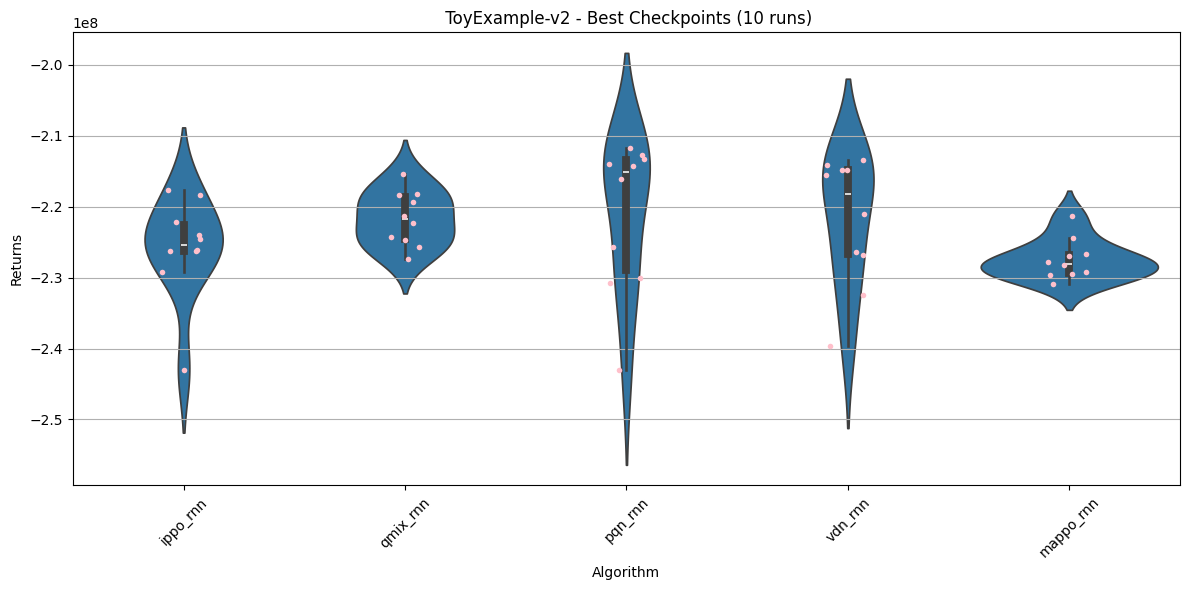

In [5]:
plt.figure(figsize=(12, 6))
sns.violinplot(x='algorithm', y='mean', data=best_means_per_run)
sns.stripplot(x='algorithm', y='mean', data=best_means_per_run, color='pink', alpha=1, size=4)

plt.title(f" {MAP_NAME} - Best Checkpoints (10 runs)")
plt.xlabel("Algorithm")
plt.ylabel("Returns")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()

plt.show()